# Lecture 11: Regression Inference

---

## Outline

* [Regression Model](#Regression-Model)
* [Prediction Variability](#Prediction-Variability)
* [The True Slope](#The-True-Slope)

---

## Set Up the Notebook

In [1]:
from datascience import *
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

def draw_and_compare(true_slope, true_int, sample_size):
    x = np.random.normal(50, 5, sample_size)
    xlims = np.array([np.min(x), np.max(x)])
    eps = np.random.normal(0, 6, sample_size)
    y = (true_slope*x + true_int) + eps
    tyche = Table().with_columns(
        'x', x,
        'y', y
    )

    plt.figure(figsize=(6, 16))
    plt.subplot(4, 1, 1)
    plt.scatter(tyche['x'], tyche['y'], s=20)
    plt.plot(xlims, true_slope*xlims + true_int, lw=2, color='green')
    plt.title('True Line, and Points Created')

    plt.subplot(4, 1, 2)
    plt.scatter(tyche['x'],tyche['y'], s=20)
    plt.title('What We Get to See')
    plt.subplot(4, 1, 3)
    scatter_fit(tyche, 'x', 'y')
    plt.xlabel("")
    plt.ylabel("")
    plt.title('Regression Line: Estimate of True Line')

    plt.subplot(4, 1, 4)
    scatter_fit(tyche, 'x', 'y')
    plt.ylabel("")
    xlims = np.array([np.min(tyche['x']), np.max(tyche['x'])])
    plt.plot(xlims, true_slope*xlims + true_int, lw=2, color='green')
    plt.title("Regression Line and True Line")
    
def standard_units(any_numbers):
    "Convert any array of numbers to standard units."
    return (any_numbers - np.mean(any_numbers))/np.std(any_numbers)  

def correlation(t, x, y):
    return np.mean(standard_units(t.column(x))*standard_units(t.column(y)))

def slope(table, x, y):
    r = correlation(table, x, y)
    return r * np.std(table.column(y))/np.std(table.column(x))

def intercept(table, x, y):
    a = slope(table, x, y)
    return np.mean(table.column(y)) - a * np.mean(table.column(x))

def fit(table, x, y):
    a = slope(table, x, y)
    b = intercept(table, x, y)
    return a * table.column(x) + b

def residual(table, x, y):
    return table.column(y) - fit(table, x, y)

def scatter_fit(table, x, y):
    plt.scatter(table.column(x), table.column(y), s=20)
    plt.plot(table.column(x), fit(table, x, y), lw=2, color='gold')
    plt.xlabel(x)
    plt.ylabel(y)

In [2]:
def distance(point1, point2):
    """The distance between two arrays of numbers."""
    return np.sqrt(np.sum((point1 - point2)**2))

def all_distances(training, point):
    """The distance between p (an array of numbers) and the numbers in row i of attribute_table."""
    attributes = training.drop('Class')
    def distance_from_point(row):
        return distance(point, np.array(row))
    return attributes.apply(distance_from_point)

def table_with_distances(training, point):
    """A copy of the training table with the distance from each row to array p."""
    return training.with_column('Distance', all_distances(training, point))

def closest(training, point, k):
    """A table containing the k closest rows in the training table to array p."""
    with_dists = table_with_distances(training, point)
    sorted_by_distance = with_dists.sort('Distance')
    topk = sorted_by_distance.take(np.arange(k))
    return topk

def majority(topkclasses):
    """1 if the majority of the "Class" column is 1s, and 0 otherwise."""
    ones = topkclasses.where('Class', are.equal_to(1)).num_rows
    zeros = topkclasses.where('Class', are.equal_to(0)).num_rows
    if ones > zeros:
        return 1
    else:
        return 0

def classify(training, p, k):
    """Classify an example with attributes p using k-nearest neighbor classification with the given training table."""
    closestk = closest(training, p, k)
    topkclasses = closestk.select('Class')
    return majority(topkclasses)

---

## Regression Model

---

### A "Model": Signal + Noise

<img src="./signal_noise.png" width=80%>

---

### What We Get To See

<img src="./what_we_see.png" width=50%>

---

### Demo: Regression Model

Explore a few examples showing the true line, the points created, and the line produced from the sample.

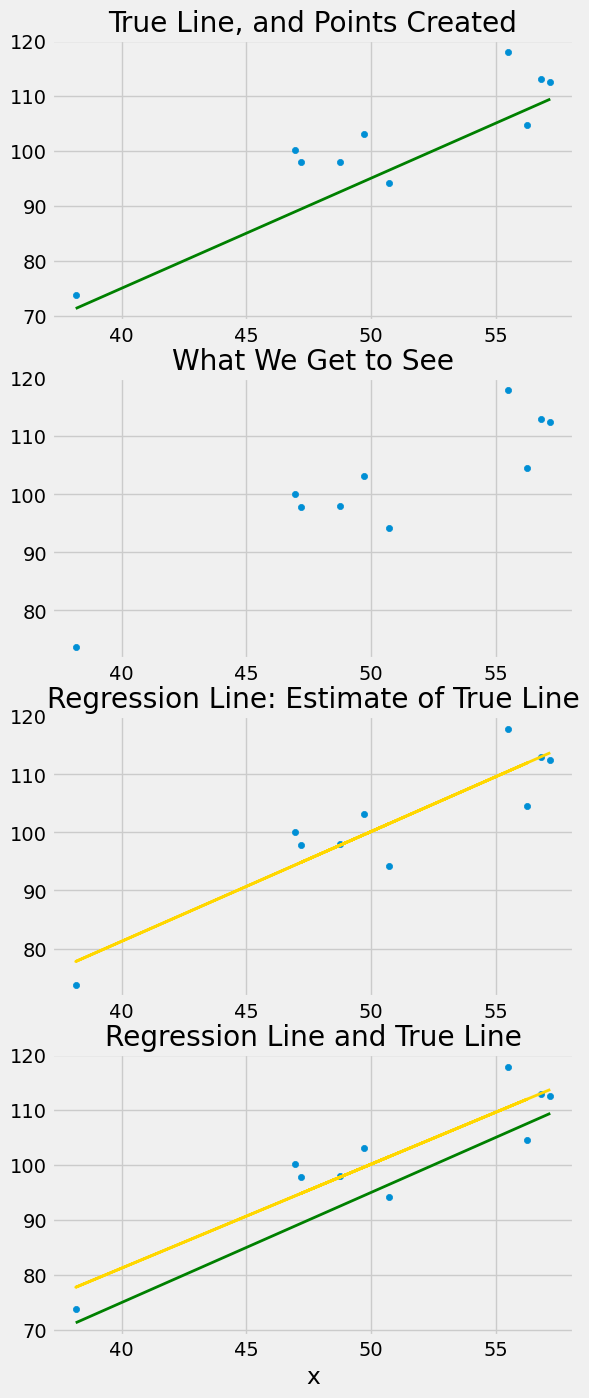

In [3]:
draw_and_compare(2, -5, 10)

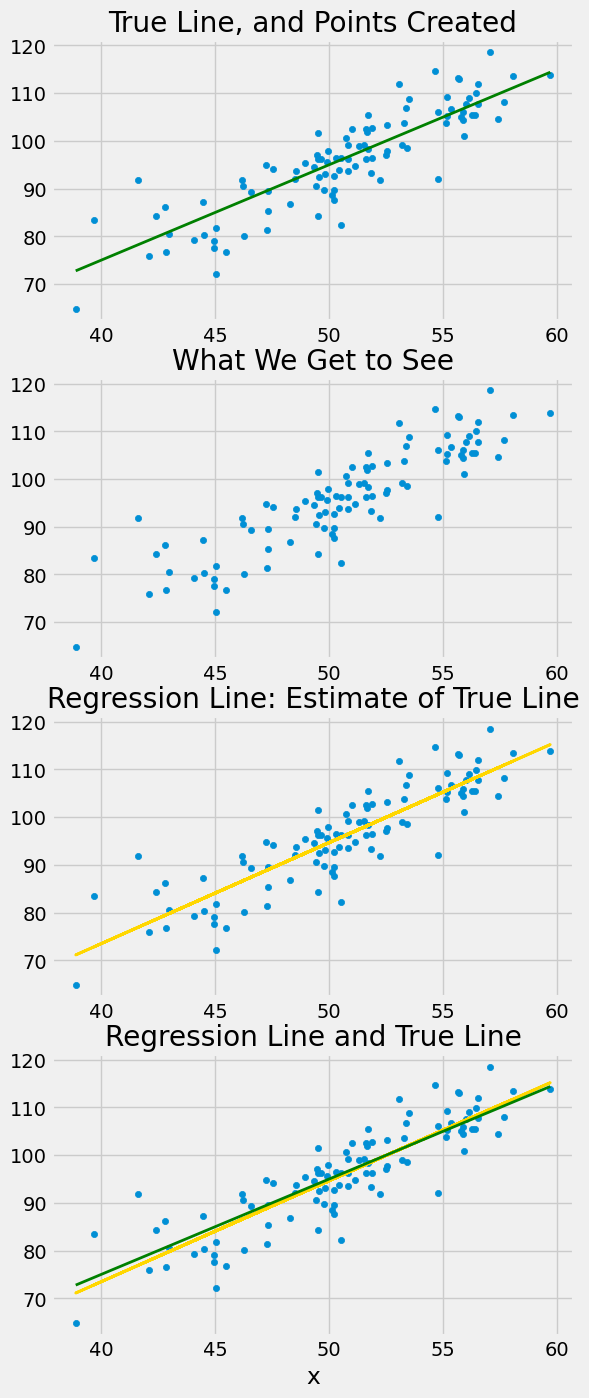

In [4]:
draw_and_compare(2, -5, 100)

---

## Prediction Variability

---

### Regression Prediction

If the data come from the regression model:
* The "true value" of the response $y$ at a given value of $x$ is the height of the true line at $x$
* We can't see the true line, so we have to estimate this height
* The regression line is most likely close to the true line
* Given a new value of $x$, predict $y$ by finding the point on the regression line at that $x$.

---

### Demo: Prediction

Explore the variability in the linear regression prediction of `Birth Weight` based on `Gestational Days` using the `baby.csv` dataset.

In [5]:
births = Table.read_table('baby.csv')
births.show(3)

Birth Weight,Gestational Days,Maternal Age,Maternal Height,Maternal Pregnancy Weight,Maternal Smoker
120,284,27,62,100,False
113,282,33,64,135,False
128,279,28,64,115,True


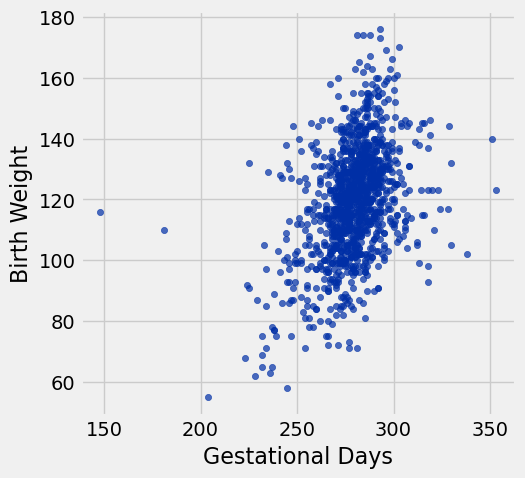

In [52]:
births.scatter('Gestational Days', 'Birth Weight')

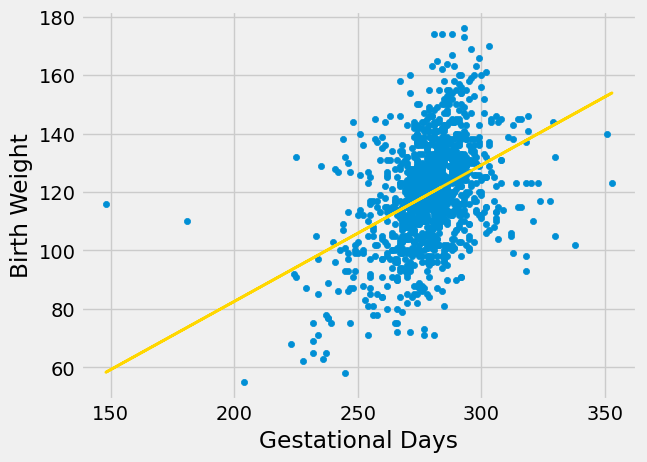

In [55]:
scatter_fit(births, 'Gestational Days', 'Birth Weight')

In [53]:
# Define data in the top or bottom 2.5 percentile as outliers
percentile_2_5 = percentile(2.5, births.column('Gestational Days'))
percentile_97_5 = percentile(97.5, births.column('Gestational Days'))
print(f'The middle 95% of the gestational days are \
between {percentile_2_5} days and {percentile_97_5} days.')

The middle 95% of the gestational days are between 243 days and 308 days.


In [8]:
correlation(births, 'Gestational Days', 'Birth Weight')

0.40754279338885108

In [56]:
slope(births, 'Gestational Days', 'Birth Weight')

0.46655687694921522

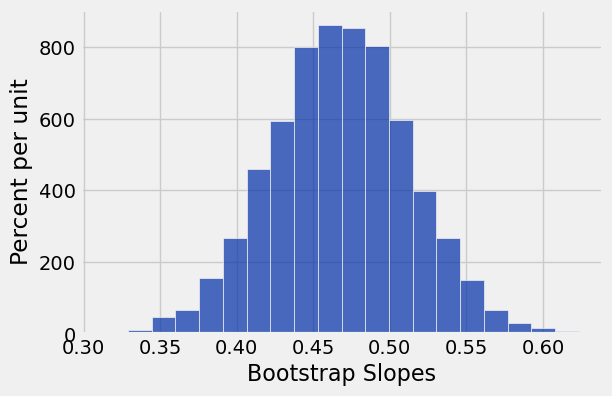

In [57]:
slopes = make_array()
for i in np.arange(5000):
    bootstrap_sample = births.sample()
    bootstrap_slope = slope(bootstrap_sample, 'Gestational Days', 'Birth Weight')
    slopes = np.append(slopes, bootstrap_slope)
Table().with_column('Bootstrap Slopes', slopes).hist(bins=20)

In [11]:
left = percentile(2.5, slopes)
right = percentile(97.5, slopes)
left, right

(0.37734624764074137, 0.55372371864316006)

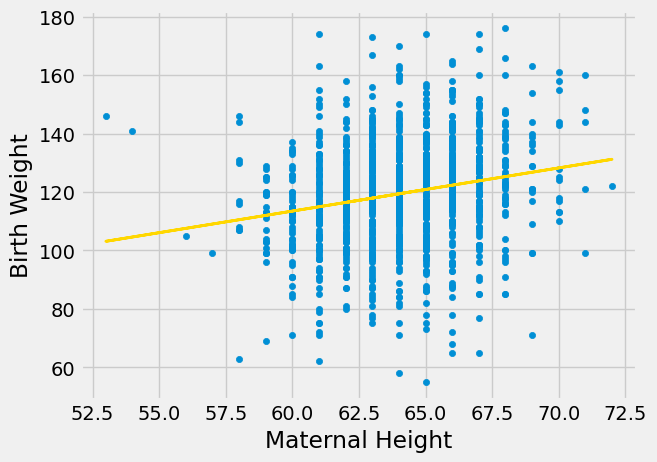

In [59]:
scatter_fit(births, 'Maternal Height', 'Birth Weight')

In [12]:
def bootstrap_slope(table, x, y, repetitions):
    
    # For each repetition:
    # Bootstrap the scatter, get the slope of the regression line,
    # augment the list of generated slopes
    slopes = make_array()
    for i in np.arange(repetitions):
        bootstrap_sample = table.sample()
        bootstrap_slope = slope(bootstrap_sample, x, y)
        slopes = np.append(slopes, bootstrap_slope)
    
    # Find the endpoints of the 95% confidence interval for the true slope
    left = percentile(2.5, slopes)
    right = percentile(97.5, slopes)
    
    # Slope of the regression line from the original sample
    observed_slope = slope(table, x, y)
    
    # Display results
    Table().with_column('Bootstrap Slopes', slopes).hist(bins=20)
    plt.plot(make_array(left, right), make_array(0, 0), color='yellow', lw=8);
    print('Slope of regression line:', observed_slope)
    print('Approximate 95%-confidence interval for the true slope:')
    print(left, right)

Slope of regression line: 0.466556876949
Approximate 95%-confidence interval for the true slope:
0.383355916135 0.555680598936


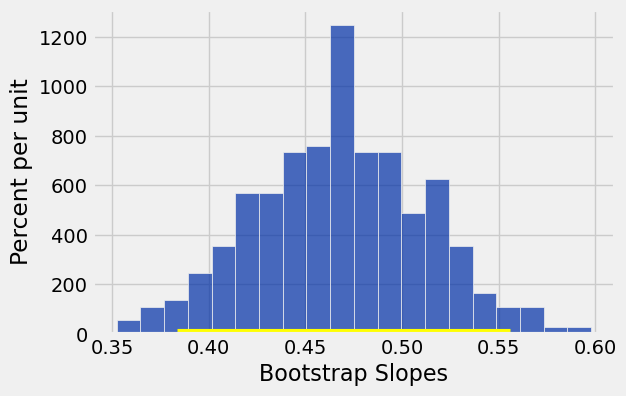

In [14]:
prediction_at_300 = bootstrap_slope(births, 'Gestational Days', 'Birth Weight', 300)
prediction_at_300

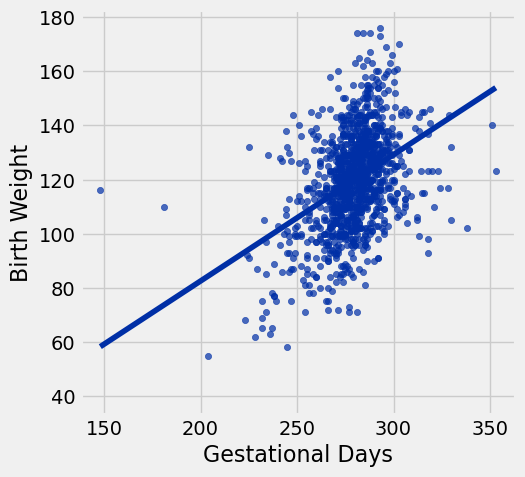

In [15]:
x = 300
births.scatter('Gestational Days', 'Birth Weight', fit_line=True)
plt.plot([x, x], [40, prediction_at_300], color='gold', lw=2);

---

### Confidence Interval for Prediction

* Bootstrap the scatter plot
* Get a prediction for y using the regression line that goes through the resampled plot
* Repeat the two steps above many times
* Draw the empirical histogram of all the predictions.
* Get the "middle 95%" interval.
* That's an approximate 95% confidence interval for the height of the true line at y.

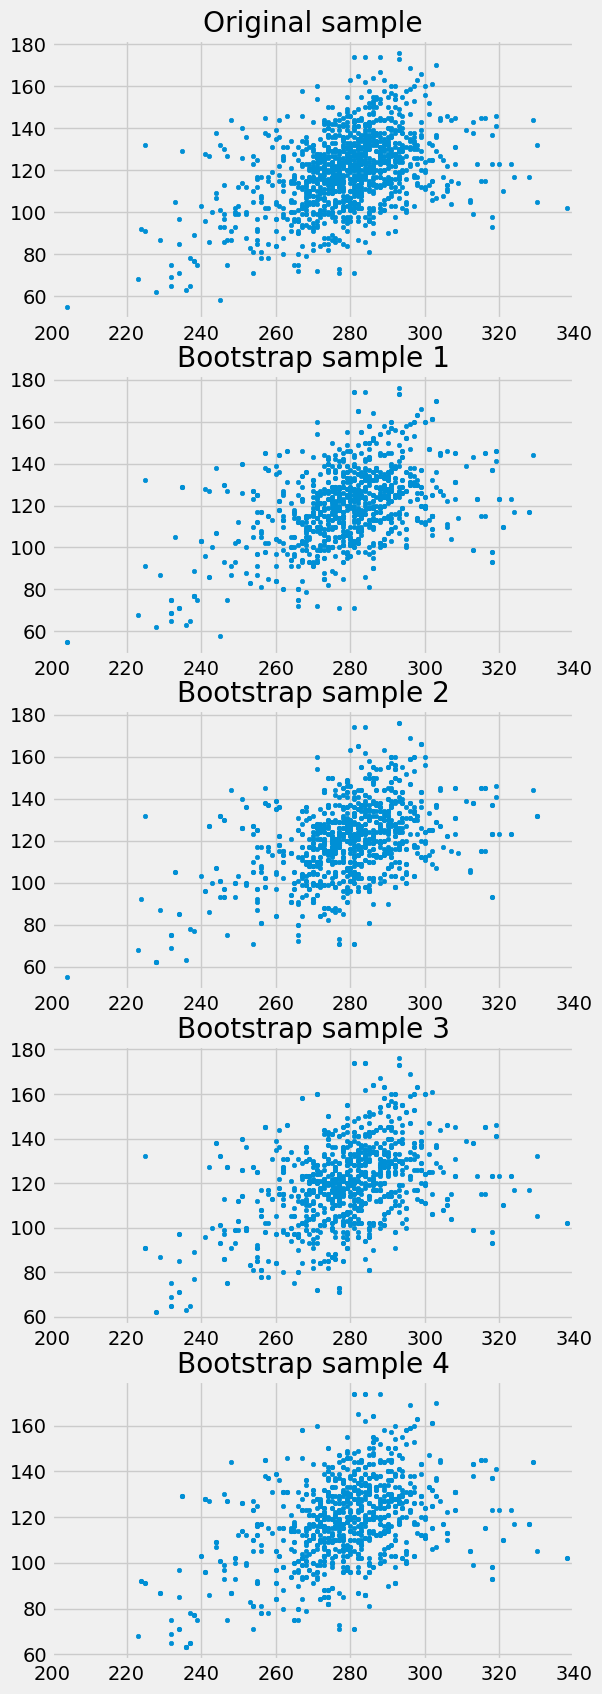

In [16]:
plt.figure(figsize=(6, 20))
plt.subplot(5, 1, 1)
plt.scatter(births[1], births[0], s=10)
plt.xlim([200, 340])
plt.title('Original sample')

for i in np.arange(1, 5, 1):
    plt.subplot(5,1,i+1)
    rep = births.sample()
    plt.scatter(rep[1], rep[0], s=10)
    plt.xlim([200, 340])
    plt.title('Bootstrap sample '+str(i))

In [17]:
def bootstrap_slope(table, x, y, repetitions):
    
    # For each repetition:
    # Bootstrap the scatter, get the slope of the regression line,
    # augment the list of generated slopes
    slopes = make_array()
    for i in np.arange(repetitions):
        bootstrap_sample = table.sample()
        bootstrap_slope = slope(bootstrap_sample, x, y)
        slopes = np.append(slopes, bootstrap_slope)
    
    # Find the endpoints of the 95% confidence interval for the true slope
    left = percentile(2.5, slopes)
    right = percentile(97.5, slopes)
    
    # Slope of the regression line from the original sample
    observed_slope = slope(table, x, y)
    
    # Display results
    Table().with_column('Bootstrap Slopes', slopes).hist(bins=20)
    plt.plot(make_array(left, right), make_array(0, 0), color='yellow', lw=8);
    print('Slope of regression line:', observed_slope)
    print('Approximate 95%-confidence interval for the true slope:')
    print(left, right)

---

Observe the variation in the regression lines made from each sample.

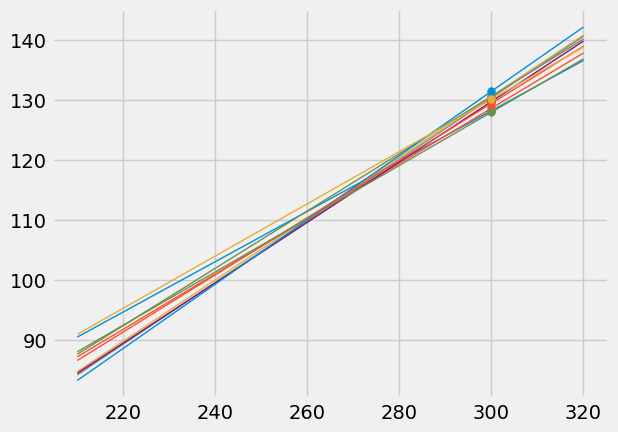

In [18]:
lines = Table(['slope','intercept', 'at 210', 'at 300', 'at 320'])

for i in range(10):
    resample = births.sample()
    a = slope(resample, 'Gestational Days', 'Birth Weight')
    b = intercept(resample, 'Gestational Days', 'Birth Weight')
    lines.append([a, b, a * 210 + b, a * 300 + b, a * 320 + b])

for i in np.arange(lines.num_rows):
    line = lines.row(i)
    plt.plot([210, 320], [line.item('at 210'), line.item('at 320')], lw=1)
    plt.scatter(300, line.item('at 300'), s=30, zorder=3)

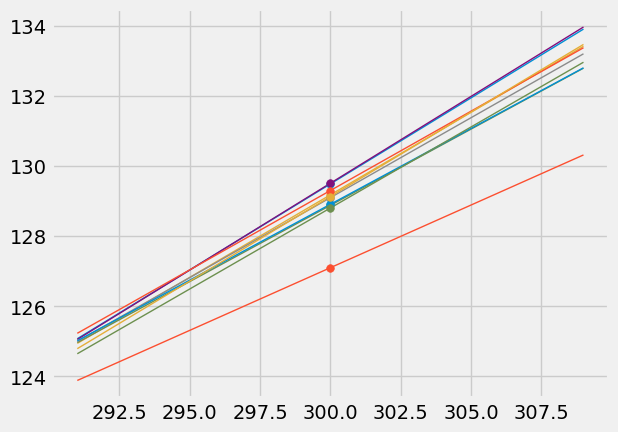

In [19]:
lines = Table(['slope','intercept', 'at 291', 'at 300', 'at 309'])

for i in range(10):
    resample = births.sample()
    a = slope(resample, 'Gestational Days', 'Birth Weight')
    b = intercept(resample, 'Gestational Days', 'Birth Weight')
    lines.append([a, b, a * 291 + b, a * 300 + b, a * 309 + b])

for i in np.arange(lines.num_rows):
    line = lines.row(i)
    plt.plot([291, 309], [line.item('at 291'), line.item('at 309')], lw=1)
    plt.scatter(300, line.item('at 300'), s=30, zorder=3)

---

### Demo: Confidence Interval for Prediction

Construct a confidence interval for the height of the true line.

In [20]:
def bootstrap_prediction(table, x, y, new_x, repetitions=1000):

        # For each repetition:
    # Bootstrap the scatter, get the slope of the regression line,
    # augment the list of generated slopes
    slopes = make_array()
    for i in np.arange(repetitions):
        bootstrap_sample = table.sample()
        bootstrap_slope = slope(bootstrap_sample, x, y)
        slopes = np.append(slopes, bootstrap_slope)
    
    # Find the endpoints of the 95% confidence interval for the true slope
    left = percentile(2.5, slopes)
    right = percentile(97.5, slopes)
    
    # Slope of the regression line from the original sample
    observed_slope = slope(table, x, y)
    
    # Display results
    Table().with_column('Bootstrap Slopes', slopes).hist(bins=20)
    plt.plot(make_array(left, right), make_array(0, 0), color='yellow', lw=8);
    print('Slope of regression line:', observed_slope)
    print('Approximate 95%-confidence interval for the true slope:')
    print(left, right)

Slope of regression line: 0.466556876949
Approximate 95%-confidence interval for the true slope:
0.377777514879 0.555373521193


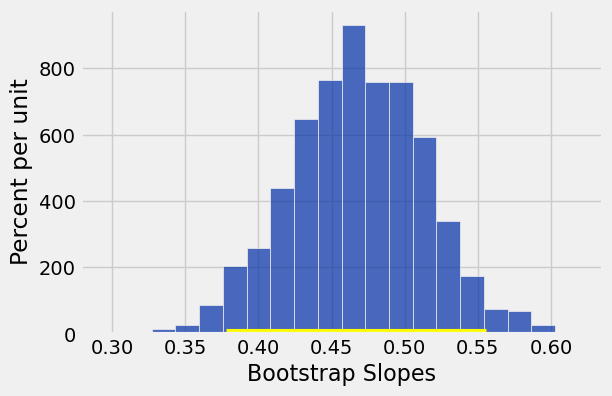

In [29]:
bootstrap_prediction(births, 'Gestational Days', 'Birth Weight', 300)

---

### Predictions at Different Values of $x$

* Since $y$ is correlated with $x$, the predicted values of $y$ depend on the value of $x$.
* The width of the prediction's CI also depends on $x$.
* Typically, intervals are wider for values of $x$ that are further away from the mean of $x$.

---

### Demo: Predictions at Different Values of $x$

Explore predictions made for different values of $x$.

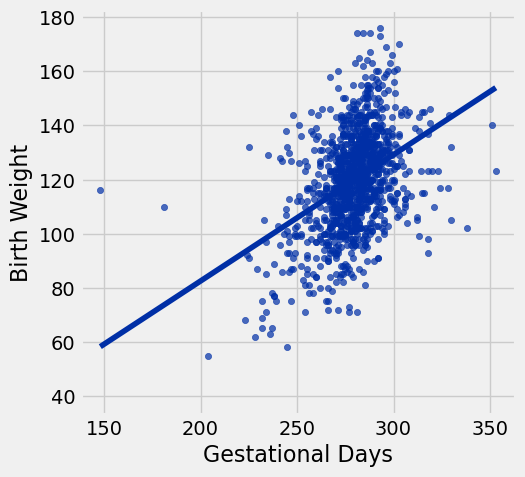

In [21]:
x = 300
births.scatter('Gestational Days', 'Birth Weight', fit_line=True)
plt.plot([x, x], [40, prediction_at_300], color='gold', lw=2);

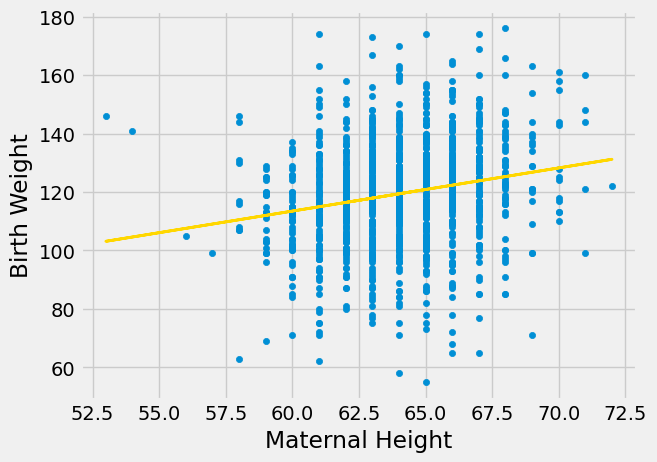

In [22]:
scatter_fit(births, 'Maternal Height', 'Birth Weight')

Slope of regression line: 0.466556876949
Approximate 95%-confidence interval for the true slope:
0.378012245072 0.560028396598


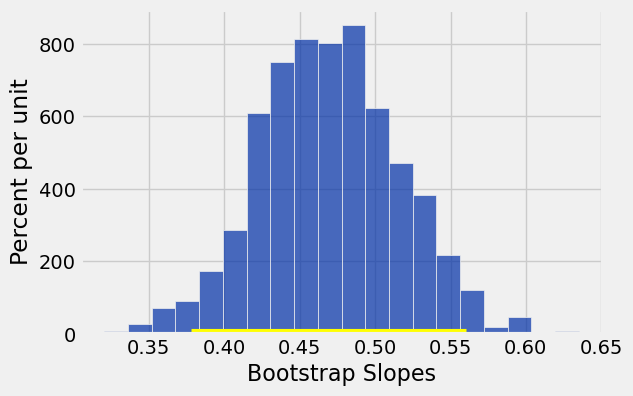

In [23]:
bootstrap_prediction(births, 'Gestational Days', 'Birth Weight', 280)

In [24]:
np.mean(births.column('Gestational Days'))

279.10136286201021

In [62]:
def fitted_value(table, x, y, given_x):
    a = slope(table, x, y)
    b = intercept(table, x, y)
    return a * given_x  + b

In [63]:
fit_300 = fitted_value(births, 'Gestational Days', 'Birth Weight', 300)
fit_300

129.2129241703143

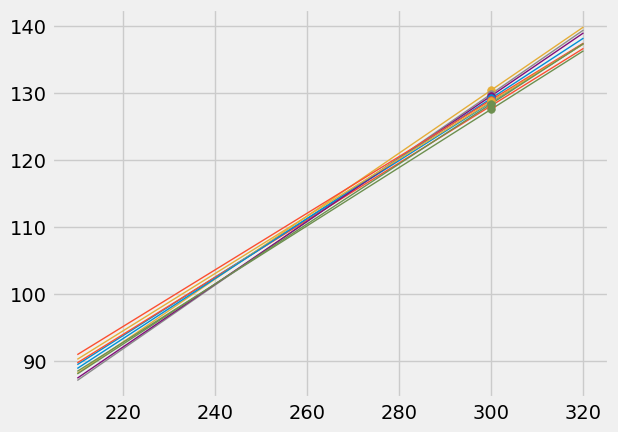

In [25]:
lines = Table(['slope','intercept', 'at 210', 'at 300', 'at 320'])

for i in range(10):
    resample = births.sample()
    a = slope(resample, 'Gestational Days', 'Birth Weight')
    b = intercept(resample, 'Gestational Days', 'Birth Weight')
    lines.append([a, b, a * 210 + b, a * 300 + b, a * 320 + b])

for i in np.arange(lines.num_rows):
    line = lines.row(i)
    plt.plot([210, 320], [line.item('at 210'), line.item('at 320')], lw=1)
    plt.scatter(300, line.item('at 300'), s=30, zorder=3)

---

## The True Slope

---

### Confidence Interval for True Slope

* Bootstrap the scatter plot.
* Find the slope of the regression line through the bootstrapped plot.
* Repeat.
* Draw the empirical histogram of all the generated slopes.
* Get the "middle 95%" interval.
* That's an approximate 95% confidence interval for the slope of the true line.


---

---

### Rain on the Regression Parade

<img src="./rain.png" width=60%>

---

### Test Whether There Really is a Slope

* Null hypothesis: The slope of the true line is 0.
* Alternative hypothesis: No, it's not.
* Method:
    * Construct a bootstrap confidence interval for the true slope.
    * If the interval doesn't contain 0, the data are more consistent with the alternative
    * If the interval does contain 0, the data are more consistent with the null


---

### Demo: Test Whether There Really is a Slope

Test whether Maternal Age and Birth Weight are correlated using the following hypotheses:

**Null Hypothesis.** Slope of true line = 0.

**Alternative Hypothesis.** Slope of true line is not 0.

In [26]:
slope(births, 'Maternal Age', 'Birth Weight')

0.085007669415825132

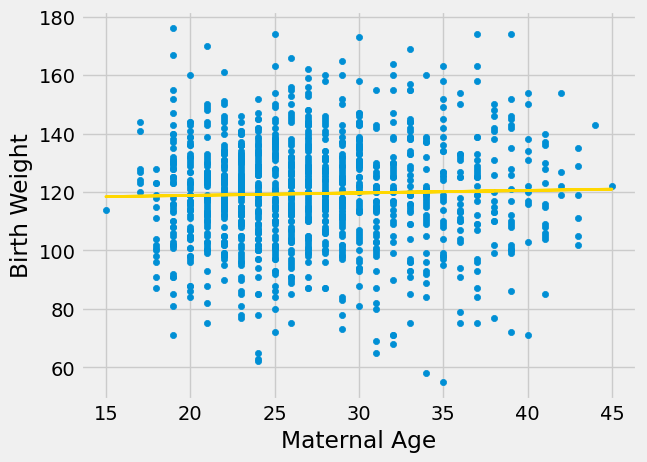

In [27]:
scatter_fit(births, 'Maternal Age', 'Birth Weight')

Slope of regression line: 0.0850076694158
Approximate 95%-confidence interval for the true slope:
-0.10286823741 0.274640398718


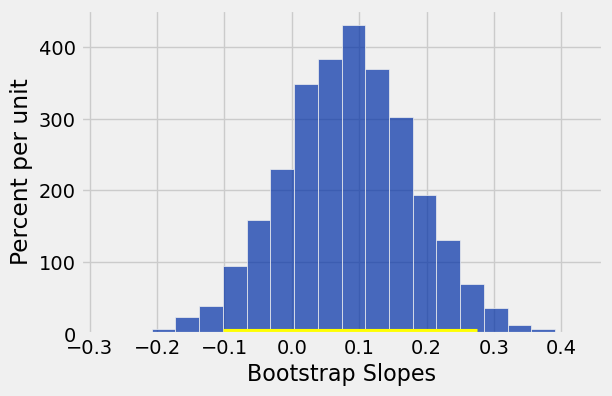

In [28]:
bootstrap_slope(births, 'Maternal Age', 'Birth Weight', 5000)

---

# Classification

---

## Outline

* [Prediction](#Prediction)
* [Classification Examples](#Classification-Examples)
* [Classification through Feature Relationships](#Classification-through-Feature-Relationships)

---

## Prediction

---

### Guessing the Value of an Attribute

* Based on incomplete information
* One way of making predictions: 
    * To predict an outcome for an individual, 
    * find others who are like that individual
    * and whose outcomes you know. 
    * Use those outcomes as the basis of your prediction.
* Two Types of Prediction
    * Classification = Categorical
    * Regression = Numeric


---

### Prediction Example: Visual Plant Identification

<a href="https://unsplash.com/photos/purple-flower-in-tilt-shift-lens-OBtrCoiKlZo" title="purple flower in tilt shift lens"><img src="./iris.avif" alt="an iris plant" width=40%></a>

* What type of plant is this?
* How do we train a computer to make this decision?

---

### Machine Learning Algorithm

* A mathematical model
* calculated based on sample data ("training data")
* that makes predictions or decisions
* without being explicitly programmed to perform the task

---

## Classification Examples

## Classification through Feature Relationships

* How can data be used to perform classification?
* The relationship between various attributes (features) might reveal patterns! 
* The choice of attributes and the number of attributes can have a big impact on identifying classes.

---

### Classiying Chronic Kidney Disease

According to the [National Kidney Foundation](https://www.kidney.org/kidney-topics/chronic-kidney-disease-ckd):

> Your kidneys do many important jobs. Some of the ways they keep your whole body in balance include:
> 
> * Removing natural waste products and extra water from your body
> * Helping make red blood cells
> * Balancing important minerals in your body
> * Helping maintain your blood pressure
> * Keeping your bones healthy
> 
> Chronic kidney disease (CKD) is when the kidneys have become damaged over time (for at least 3 months) and have a hard time doing all their important jobs. CKD also increases the risk of other health problems like heart disease and stroke.

Your bodily measurements, such as white blood cell count, glucose levels, hemoglobin levels, etc., can help predict whether or not you are experiencing CKD.

---

### Demo: Classifying Chronic Kidney Disease

* Load the `ckd.csv` data that shows patient data. Group the data by class to see how many patients have been labeled as having chronic kidney disease (`1`) or not (`0`).
* Visualize the relationship between `'White Blood Cell Count'` and `'Glucose'` to see if these features might be helpful to identify CKD. Look for separation in the colored points.
* Visualize the relationship between `'Hemoglobin'` and `'Glucose'` to see if these features might be helpful to identify CKD.
* Explore how the natural boundaries in the scatterplot can be used to classify a patient as having CKD or not. Create a function to predict a patient's class based on their hemoglobin and glucose levels based on the visualized boundaries.
* Try out the classifier and think about its limitations.

In [64]:
ckd = Table.read_table('ckd.csv').relabeled('Blood Glucose Random', 'Glucose')
ckd

Age,Blood Pressure,Specific Gravity,Albumin,Sugar,Red Blood Cells,Pus Cell,Pus Cell clumps,Bacteria,Glucose,Blood Urea,Serum Creatinine,Sodium,Potassium,Hemoglobin,Packed Cell Volume,White Blood Cell Count,Red Blood Cell Count,Hypertension,Diabetes Mellitus,Coronary Artery Disease,Appetite,Pedal Edema,Anemia,Class
48,70,1.005,4,0,normal,abnormal,present,notpresent,117,56,3.8,111,2.5,11.2,32,6700,3.9,yes,no,no,poor,yes,yes,1
53,90,1.02,2,0,abnormal,abnormal,present,notpresent,70,107,7.2,114,3.7,9.5,29,12100,3.7,yes,yes,no,poor,no,yes,1
63,70,1.01,3,0,abnormal,abnormal,present,notpresent,380,60,2.7,131,4.2,10.8,32,4500,3.8,yes,yes,no,poor,yes,no,1
68,80,1.01,3,2,normal,abnormal,present,present,157,90,4.1,130,6.4,5.6,16,11000,2.6,yes,yes,yes,poor,yes,no,1
61,80,1.015,2,0,abnormal,abnormal,notpresent,notpresent,173,148,3.9,135,5.2,7.7,24,9200,3.2,yes,yes,yes,poor,yes,yes,1
48,80,1.025,4,0,normal,abnormal,notpresent,notpresent,95,163,7.7,136,3.8,9.8,32,6900,3.4,yes,no,no,good,no,yes,1
69,70,1.01,3,4,normal,abnormal,notpresent,notpresent,264,87,2.7,130,4,12.5,37,9600,4.1,yes,yes,yes,good,yes,no,1
73,70,1.005,0,0,normal,normal,notpresent,notpresent,70,32,0.9,125,4,10,29,18900,3.5,yes,yes,no,good,yes,no,1
73,80,1.02,2,0,abnormal,abnormal,notpresent,notpresent,253,142,4.6,138,5.8,10.5,33,7200,4.3,yes,yes,yes,good,no,no,1
46,60,1.01,1,0,normal,normal,notpresent,notpresent,163,92,3.3,141,4,9.8,28,14600,3.2,yes,yes,no,good,no,no,1


In [65]:
ckd = Table().with_columns(
    'Hemoglobin', standard_units(ckd.column('Hemoglobin')),
    'Glucose', standard_units(ckd.column('Glucose')),
    'White Blood Cell Count', standard_units(ckd.column('White Blood Cell Count')),
    'Class', ckd.column('Class')
)

In [66]:
ckd

Hemoglobin,Glucose,White Blood Cell Count,Class
-0.865744,-0.221549,-0.569768,1
-1.45745,-0.947597,1.16268,1
-1.00497,3.84123,-1.27558,1
-2.81488,0.396364,0.809777,1
-2.08395,0.643529,0.232293,1
-1.35303,-0.561402,-0.505603,1
-0.413266,2.04928,0.360623,1
-1.28342,-0.947597,3.34429,1
-1.10939,1.87936,-0.409356,1
-1.35303,0.489051,1.96475,1


In [67]:
color_table = Table().with_columns(
    'Class', make_array(1, 0),
    'Color', make_array('darkblue', 'gold')
)
ckd = ckd.join('Class', color_table)

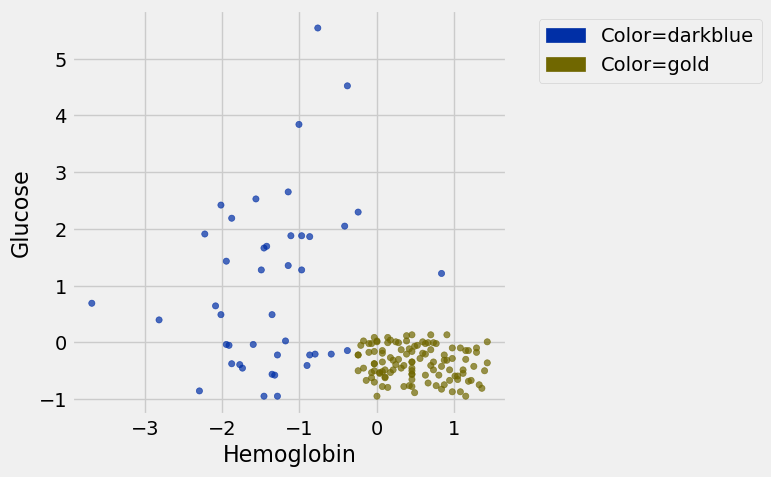

In [68]:
ckd.scatter('Hemoglobin', 'Glucose', group='Color')

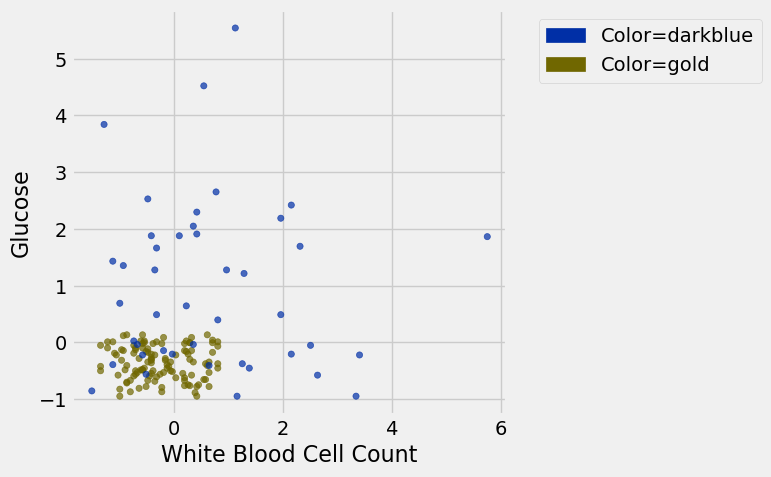

In [34]:
ckd.scatter('White Blood Cell Count', 'Glucose', group='Color')

In [35]:
def show_closest(point):
    """point = array([x,y]) 
    gives the coordinates of a new point
    shown in red"""
    
    HemoGl = ckd.drop('White Blood Cell Count', 'Color')
    t = closest(HemoGl, point, 1)
    x_closest = t.row(0).item(1)
    y_closest = t.row(0).item(2)
    ckd.scatter('Hemoglobin', 'Glucose', group='Color')
    plt.scatter(point.item(0), point.item(1), color='red', s=30)
    plt.plot(make_array(point.item(0), x_closest), make_array(point.item(1), y_closest), color='k', lw=2);

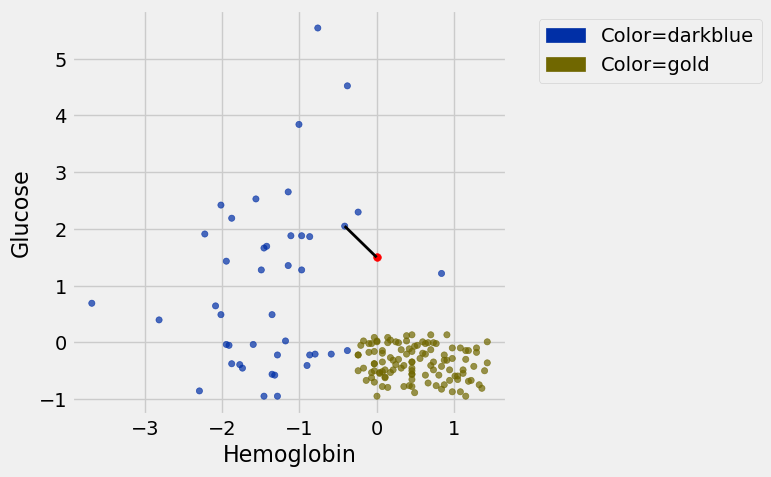

In [36]:
# In this example, Alice's Hemoglobin attribute is 0 and her Glucose is 1.5.
alice = make_array(0, 1.5)
show_closest(alice)

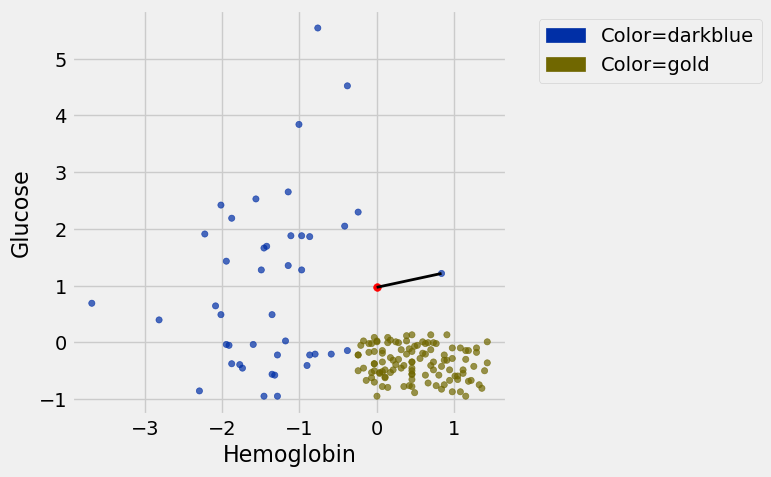

In [37]:
alice = make_array(0, 0.97)
show_closest(alice)

In [38]:
x_array = make_array()
y_array = make_array()
for x in np.arange(-2, 2.1, 0.1):
    for y in np.arange(-2, 2.1, 0.1):
        x_array = np.append(x_array, x)
        y_array = np.append(y_array, y)
        
test_grid = Table().with_columns(
    'Hemoglobin', x_array,
    'Glucose', y_array
)

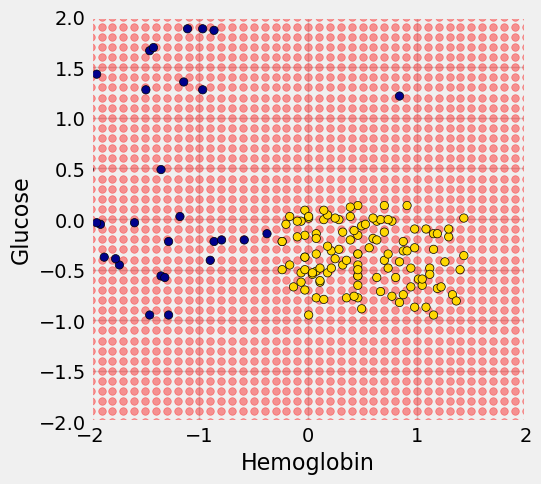

In [39]:
test_grid.scatter('Hemoglobin', 'Glucose', color='red', alpha=0.4, s=30)

plt.scatter(ckd.column('Hemoglobin'), ckd.column('Glucose'), c=ckd.column('Color'), edgecolor='k')

plt.xlim(-2, 2)
plt.ylim(-2, 2);

In [40]:
def classify_grid(training, test, k):
    c = make_array()
    for i in range(test.num_rows):
        # Run the classifier on the ith patient in the test set
        c = np.append(c, classify(training, make_array(test.row(i)), k))   
    return c


In [41]:
c = classify_grid(ckd.drop('White Blood Cell Count', 'Color'), test_grid, 1)

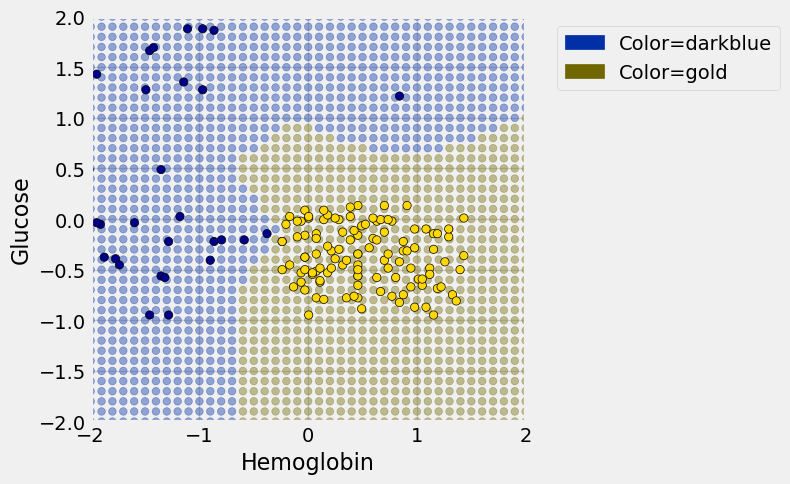

In [42]:
test_grid = test_grid.with_column('Class', c).join('Class', color_table)
test_grid.scatter('Hemoglobin', 'Glucose', group='Color', alpha=0.4, s=30)

plt.scatter(ckd.column('Hemoglobin'), ckd.column('Glucose'), c=ckd.column('Color'), edgecolor='k')

plt.xlim(-2, 2)
plt.ylim(-2, 2);

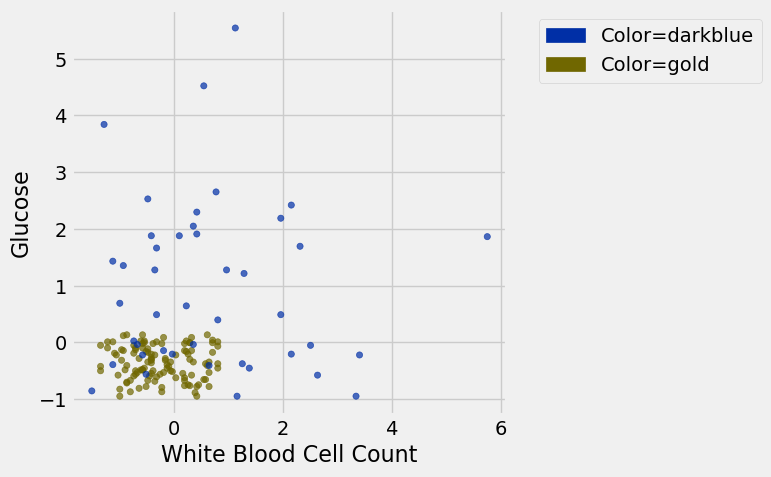

In [43]:
ckd.scatter('White Blood Cell Count', 'Glucose', group='Color')

### Classifying Banknotes

<a href="https://www.koenig-bauer.com/en/news/details/article/fast-and-reliable-authentication-of-banknotes/"><img src="./valicash.jpg" width=50% alt="ValiCash banknote app"></a>

We can use classification techniques and images of banknotes to detect forged currency.

---

#### Data and Optional Terminology

The [`banknote.csv` dataset](https://archive.ics.uci.edu/dataset/267/banknote+authentication) contains wavelet transformation (image processing) information on banknotes (bills) that have been used to classify banknotes.

- Wavelet Variance (`WaveletVar`): Measures how much the wavelet-transformed signal values vary, with bigger numbers meaning more variability.
- Wavelet Skewness (`WaveletSkew`): Measures whether the wavelet-transformed signal values lean more to the left or right.
- Wavelet Kurtosis (`WaveletCurt`): Measures whether the wavelet-transformed signal has more extreme values (heavy tails) or is more tightly clustered.
- Entropy (`Entropy`): Measures how random or unpredictable the signal is after wavelet transformation.

**Note**: You are not responsible for understanding what these terms mean for this class.


---

#### Demo: Classifying Banknotes

* Create a table called `banknotes` from `banknote.csv`.
* Notice that the dataset has two classes of banknotes (genuine and forged).
* Explore the relationship between `WaveletVar` and `WaveletCurt` to see if they are helpful features for classifying the banknotes.
* Explore the relationship between `WaveletSkew` and `Entropy` to see if they are helpful features for classifying the banknotes.
* Sometimes you need to adjust the number of features you relate to identify clear separation in the data! Let's see how all three wavelet features can be used to identify the class visually (in 4D).

In [44]:
banknotes = Table.read_table('banknote.csv')
banknotes

WaveletVar,WaveletSkew,WaveletCurt,Entropy,Class
3.6216,8.6661,-2.8073,-0.44699,0
4.5459,8.1674,-2.4586,-1.4621,0
3.866,-2.6383,1.9242,0.10645,0
3.4566,9.5228,-4.0112,-3.5944,0
0.32924,-4.4552,4.5718,-0.9888,0
4.3684,9.6718,-3.9606,-3.1625,0
3.5912,3.0129,0.72888,0.56421,0
2.0922,-6.81,8.4636,-0.60216,0
3.2032,5.7588,-0.75345,-0.61251,0
1.5356,9.1772,-2.2718,-0.73535,0


In [45]:
color_table = Table().with_columns(
    'Class', make_array(1, 0),
    'Color', make_array('darkblue', 'gold')
)

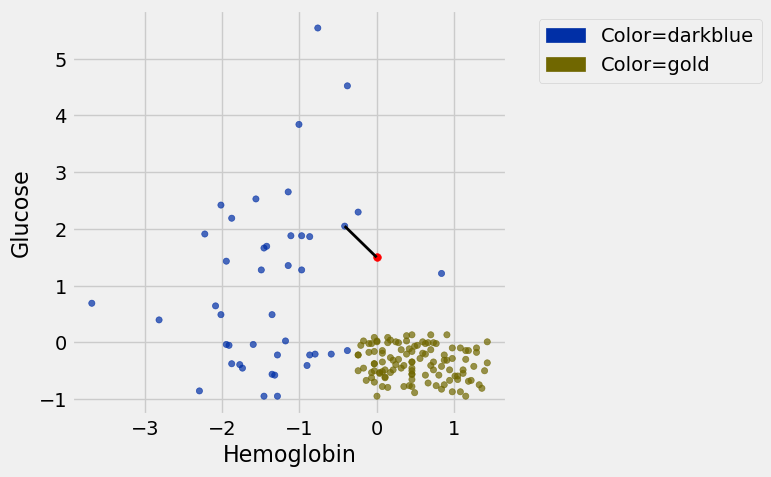

In [69]:
# In this example, Alice's Hemoglobin attribute is 0 and her Glucose is 1.5.
alice = make_array(0, 1.5)
show_closest(alice)

In [46]:
banknotes = banknotes.join('Class', color_table)

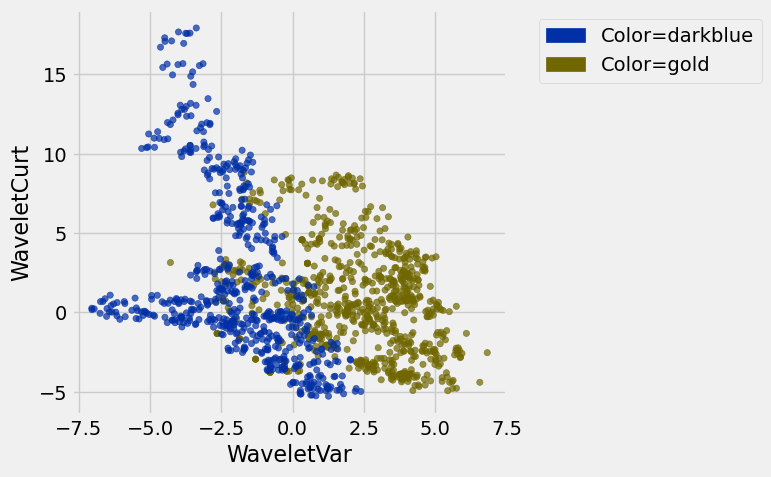

In [47]:
banknotes.scatter('WaveletVar', 'WaveletCurt', group='Color')

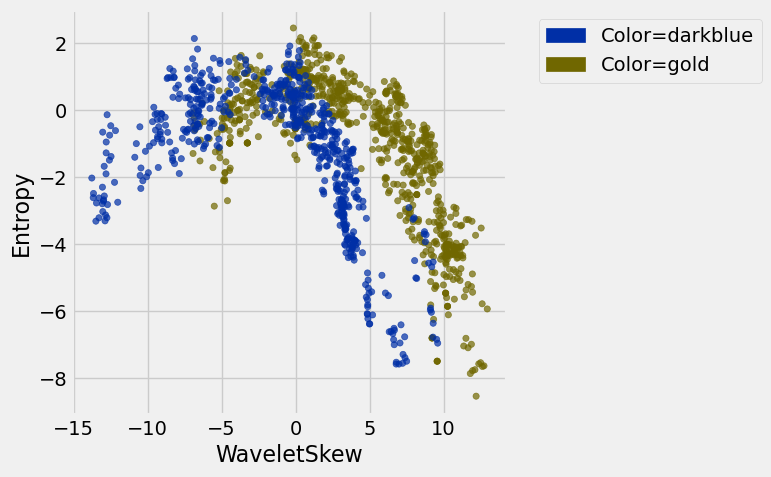

In [48]:
banknotes.scatter('WaveletSkew', 'Entropy', group='Color')

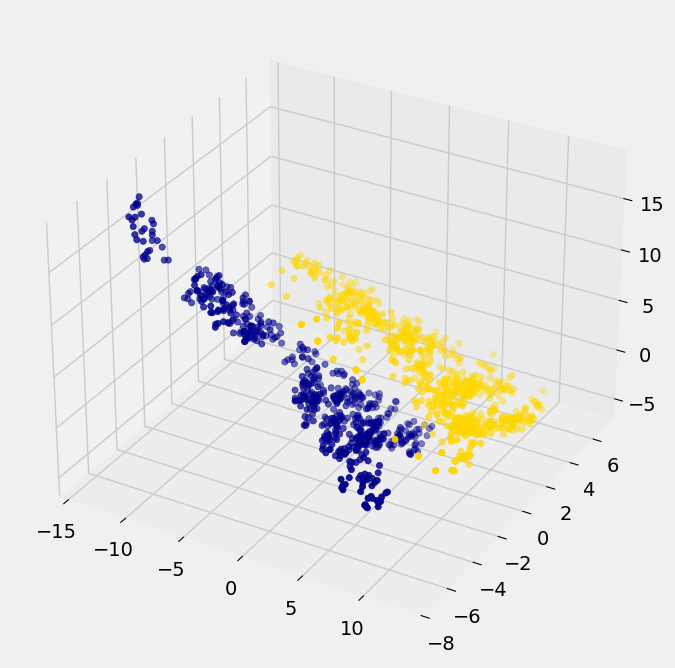

In [49]:

ax = plt.figure(figsize=(8,8)).add_subplot(111, projection='3d')
ax.scatter(banknotes.column('WaveletSkew'), 
           banknotes.column('WaveletVar'), 
           banknotes.column('WaveletCurt'), 
           c=banknotes.column('Color'));

---

### Classifying using Boundaries

* In the CKD example, the visualization with glucose and hemoglobin helped us **"see"** the boundaries for CKD.
    * Using those boundaries, we created a classifier.
* In the banknote example, the visualization with Wavelet Variance, Wavelet Skew, and Wavelet Kurtosis helped us **"see"** the boundaries for a counterfeit banknote.
    * Using those boundaries, we could create another classifier.
* This method of classification, creating a threshold, has several pros and cons.
    * Pro: Fast! 💨
    * Con: Struggles with complex or overlapping data 
* Is there another way to classify?
    * Yes!
    * There are several, but you'll learn about one specific method **in the next lecture**.

---

# Implementing Classifiers

---

## Outline

* [Implementing a Classifier](#Implementing-a-Classifier)
* [Feature Selection](#Feature-Selection)
* [Review of Rows](#Review-of-Rows)
* [Calculating Distance](#Calculating-Distance)
* [Splitting the Data](#Splitting-the-Data)
* [Nearest Neighbors](#Nearest-Neighbors)

---

## Implementing a Classifier

---

### A Process

```mermaid
graph TD
    A["Population"] --> B["Sample with labels"]

    B -->|"x% of Sample"| C["Create Training Set"]
    B -->|"y% of Sample"| V["Create Validation Set"]
    B -->|"100-x-y% of Sample"| D["Create Test Set"]

    C --> E["Train classifier on Training Set"]
    E --> F["Fine-Tune Classifier using Validation Set"]
    V --> F

   F --> H["Evaluate Classifier with Test Set"]
   D --> H
   
    H --> I["Apply Model"]
```

---

### $k$ Nearest Neighbor Classification

- A nearest neighbor classifier assigns a label to an unlabeled point by using the **majority label** of **nearby** points
- The number of nearby points considered is called **$k$** and can vary depending on the classifier
- For this lecture, let's explore a way to
    - Calculate distance
    - Split the sample into a training set and a set that will be used for validation and testing
    - Determine the nearby points
    - Calculate the majority label

---

## Feature Selection

---

### Reviewing the Features

* From the previous lecture, we showed you the chronic kidney disease (CKD) data set
* Each row represented an individual
* Each column was a feature of the individual
* The class label was a label indicating whether they were diagnosed with CKD (`1`) or not (`0`)

In [50]:
ckd = Table.read_table('ckd.csv').relabeled('Blood Glucose Random', 'Glucose')
ckd.sample(3).show(3)

Age,Blood Pressure,Specific Gravity,Albumin,Sugar,Red Blood Cells,Pus Cell,Pus Cell clumps,Bacteria,Glucose,Blood Urea,Serum Creatinine,Sodium,Potassium,Hemoglobin,Packed Cell Volume,White Blood Cell Count,Red Blood Cell Count,Hypertension,Diabetes Mellitus,Coronary Artery Disease,Appetite,Pedal Edema,Anemia,Class
66,70,1.025,0,0,normal,normal,notpresent,notpresent,107,16,1.1,140,3.6,13.6,42,11000,4.9,no,no,no,good,no,no,0
75,70,1.02,0,0,normal,normal,notpresent,notpresent,107,48,0.8,144,3.5,13.6,46,10300,4.8,no,no,no,good,no,no,0
30,60,1.025,0,0,normal,normal,notpresent,notpresent,120,31,0.8,150,4.6,13.4,44,10700,5.8,no,no,no,good,no,no,0


* Which features help predict CKD?
* We saw that glucose and hemoglobin measurements can helpful

In [51]:
ckd = ckd.select('Hemoglobin', 'Glucose', 'Class')
ckd

Hemoglobin,Glucose,Class
11.2,117,1
9.5,70,1
10.8,380,1
5.6,157,1
7.7,173,1
9.8,95,1
12.5,264,1
10,70,1
10.5,253,1
9.8,163,1


---

## Rows

---

### Reviewing Rows of Tables

Each row contains all the data for one individual
* `t.row(i)` evaluates to `i`th row of table `t`
* `t.row(i).item(j)` is the value of column `j` in row `i`
* If all values are numbers, then `np.array(t.row(i))` evaluates to an array of all the numbers in the row.  
* To consider each row individually, use
* `for row in t.rows:`
    `... row.item(j) ...`
* `t.exclude(i)` evaluates to the table `t` without its `i`th row


---

In [70]:
ckd.row(0)

Row(Class=0, Hemoglobin=0.45688370171598491, Glucose=0.13375085451774507, White Blood Cell Count=0.61728251314009996, Color='gold')

In [71]:
ckd.row(0).item(3)

0.61728251314009996

In [72]:
ckd = Table().with_columns(
    'Hemoglobin', standard_units(ckd.column('Hemoglobin')),
    'Glucose', standard_units(ckd.column('Glucose')),
    'Class', ckd.column('Class')
)

color_table = Table().with_columns(
    'Class', make_array(1, 0),
    'Color', make_array('darkblue', 'gold')
)
ckd = ckd.join('Class', color_table)
ckd

Class,Hemoglobin,Glucose,Color
0,0.456884,0.133751,gold
0,1.153,-0.947597,gold
0,0.770138,-0.762223,gold
0,0.596108,-0.190654,gold
0,-0.239236,-0.49961,gold
0,-0.0304002,-0.159758,gold
0,0.282854,-0.00527964,gold
0,0.108824,-0.623193,gold
0,0.0740178,-0.515058,gold
0,0.83975,-0.422371,gold


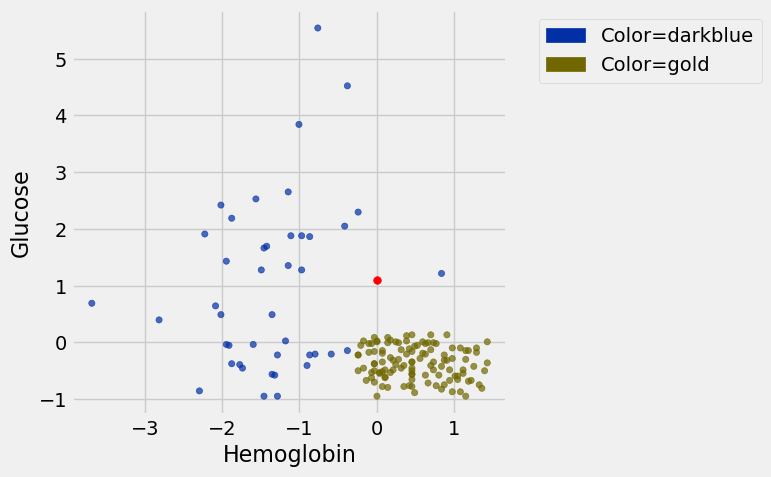

In [74]:
alice = make_array(0, 1.1)
ckd.scatter('Hemoglobin', 'Glucose', group='Color')
plt.scatter(alice.item(0), alice.item(1), color='red', s=30);

In [75]:
ckd_attributes = ckd.select('Hemoglobin', 'Glucose')

In [76]:
ckd_attributes

Hemoglobin,Glucose
0.456884,0.133751
1.153,-0.947597
0.770138,-0.762223
0.596108,-0.190654
-0.239236,-0.49961
-0.0304002,-0.159758
0.282854,-0.00527964
0.108824,-0.623193
0.0740178,-0.515058
0.83975,-0.422371


In [77]:
ckd_attributes

Hemoglobin,Glucose
0.456884,0.133751
1.153,-0.947597
0.770138,-0.762223
0.596108,-0.190654
-0.239236,-0.49961
-0.0304002,-0.159758
0.282854,-0.00527964
0.108824,-0.623193
0.0740178,-0.515058
0.83975,-0.422371


In [78]:
ckd_attributes.row(3)

Row(Hemoglobin=0.59610766482326649, Glucose=-0.19065363034327706)

In [79]:
np.array(ckd_attributes.row(3))

array([ 0.59610766, -0.19065363])

## Calculating Distance

---

### Pythagoras' Formula

<img src="./pyth.png" width=20%>

For a right triangle with legs $a, b$ and hypotenuse $c$, the following relationship is always true: $$a^2 + b^2 = c^2.$$


---

### Distance Between Two Points

One way to calculate the distance $D$ between two points utilizes a right triangle and depends on the number of attributes each point has.
* If $D$ represents the distance between points $(x_0, y_0)$ and $(x_1, y_1)$, then $$D = \sqrt{(x_0 - x_1)^2 + (y_0 - y_1)^2}$$
* If $D$ represents the distance between points $(x_0, y_0, z_0)$ and $(x_1, y_1, z_1)$, then $$D = \sqrt{(x_0 - x_1)^2 + (y_0 - y_1)^2 + (z_0 - z_1)^2}$$
* etc.

---

### Distances using Array Arithmetic

* For a table like `tbl`:

Attribute | Point 1 | Point 2 
|---|---|---|
x | x_0 | x_1 
y | y_0 | y_1
z | z_0 | z_1 
... | ... | ... 

* You can get the column (array) data:
    * `pt1 = tbl.column('Point 1')`
    * `pt2 = tbl.column('Point 2')`
* Then the distance formula with NumPy is: `np.sqrt(np.sum((pt1 - pt2)**2))`
* This formula with NumPy is the same no matter how many rows (attributes) there are!

In [80]:
patient3 = np.array(ckd_attributes.row(3))
alice, patient3

(array([ 0. ,  1.1]), array([ 0.59610766, -0.19065363]))

In [81]:
distance = np.sqrt(np.sum((alice - patient3)**2))
distance

1.4216649188818471

In [82]:
def distance(point1, point2):
    """Returns the Euclidean distance between point1 and point2.
    
    Each argument is an array containing the coordinates of a point."""
    return np.sqrt(np.sum((point1 - point2)**2))

In [83]:
t = ckd_attributes.take(np.arange(5))
t

Hemoglobin,Glucose
0.456884,0.133751
1.153,-0.947597
0.770138,-0.762223
0.596108,-0.190654
-0.239236,-0.49961


In [84]:
def max_abs(row):
    return np.max(np.abs(np.array(row)))

In [85]:
max_abs(t.row(4))

0.49961028259186963

In [86]:
t.apply(max_abs)

array([ 0.4568837 ,  1.15300352,  0.77013762,  0.59610766,  0.49961028])

In [87]:
alice

array([ 0. ,  1.1])

In [89]:
def distance_from_alice(row):
    """Returns distance between Alice and a row of the attributes table"""
    return distance(alice, np.array(row))

In [91]:
distances = ckd_attributes.apply(distance_from_alice)
ckd_with_distances = ckd.with_column('Distance from Alice', distances)

In [92]:
ckd_with_distances

Class,Hemoglobin,Glucose,Color,Distance from Alice
0,0.456884,0.133751,gold,1.06882
0,1.153,-0.947597,gold,2.34991
0,0.770138,-0.762223,gold,2.01519
0,0.596108,-0.190654,gold,1.42166
0,-0.239236,-0.49961,gold,1.6174
0,-0.0304002,-0.159758,gold,1.26012
0,0.282854,-0.00527964,gold,1.1409
0,0.108824,-0.623193,gold,1.72663
0,0.0740178,-0.515058,gold,1.61675
0,0.83975,-0.422371,gold,1.73862


In [93]:
sorted_by_distance = ckd_with_distances.sort('Distance from Alice')
sorted_by_distance

Class,Hemoglobin,Glucose,Color,Distance from Alice
1,0.83975,1.2151,darkblue,0.847601
1,-0.970162,1.27689,darkblue,0.986156
0,-0.0304002,0.0874074,gold,1.01305
0,0.14363,0.0874074,gold,1.02273
1,-0.413266,2.04928,darkblue,1.03534
0,0.387272,0.118303,gold,1.05532
0,0.456884,0.133751,gold,1.06882
0,0.178436,0.0410639,gold,1.07386
0,0.00440582,0.025616,gold,1.07439
0,-0.169624,0.025616,gold,1.08769


In [94]:
alice_5_nearest_neighbors = sorted_by_distance.take(np.arange(5))
alice_5_nearest_neighbors

Class,Hemoglobin,Glucose,Color,Distance from Alice
1,0.83975,1.2151,darkblue,0.847601
1,-0.970162,1.27689,darkblue,0.986156
0,-0.0304002,0.0874074,gold,1.01305
0,0.14363,0.0874074,gold,1.02273
1,-0.413266,2.04928,darkblue,1.03534


---

## Attribution

This content is licensed under the <a href="https://creativecommons.org/licenses/by-nc-sa/4.0/">Creative Commons Attribution-NonCommercial-ShareAlike 4.0 International License (CC BY-NC-SA 4.0)</a> and derived from the <a href="https://www.data8.org/">Data 8: The Foundations of Data Science</a> offered by the University of California, Berkeley.

<img src="./by-nc-sa.png" width=100px>